In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error,r2_score)

In [52]:
df =pd.read_csv("car data.csv")


df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [53]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [54]:
current_year=2026
df["Car_Age"]=current_year-df["Year"]
df.drop("Year",axis=1,inplace=True)

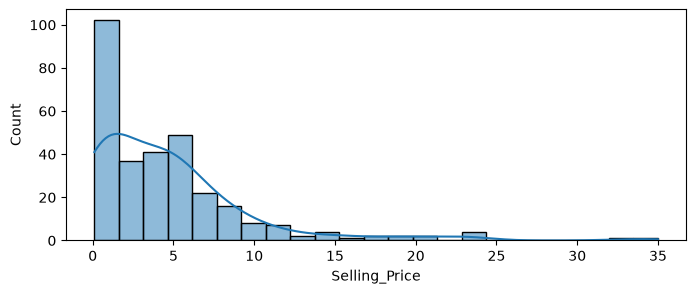

In [55]:
plt.figure(figsize=(8,3))
sns.histplot(df["Selling_Price"], kde=True)
plt.show()

In [56]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


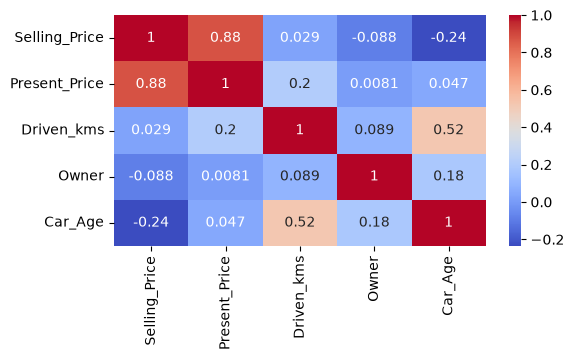

In [57]:
plt.figure(figsize=(6,3))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

In [58]:
y=df["Selling_Price"]
X = df.drop("Selling_Price", axis=1)

In [59]:
categorical_features =["Car_Name","Fuel_Type","Selling_type","Transmission"]
preprocessor = ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)],remainder="passthrough")

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [61]:
lr_pipeline = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("R2:",r2_score(y_test, lr_pred))

print("MAE:",mean_absolute_error(y_test, lr_pred))

R2: 0.8839709008202077
MAE: 1.0614836303571356


In [62]:
dt_pipeline = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeRegressor(random_state=42))])

dt_pipeline.fit(X_train, y_train)
dt_pred =dt_pipeline.predict(X_test)

print("R2:",r2_score(y_test, dt_pred))
print("MAE:",mean_absolute_error(y_test, dt_pred))

R2: 0.9548447017869949
MAE: 0.6362295081967212


In [63]:
rf_pipeline = Pipeline([("preprocessor", preprocessor),("model", RandomForestRegressor(n_estimators=200,random_state=42))])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("R2:",r2_score(y_test, rf_pred))
print("MAE:",mean_absolute_error(y_test, rf_pred))

R2: 0.9624889306773717
MAE: 0.6209893442622948


In [64]:
best_model = rf_pipeline
sample = pd.DataFrame({"Car_Name":["swift"],"Present_Price":[8.5],"Driven_kms":[35000],"Fuel_Type":["Petrol"],"Selling_type":["Dealer"],"Transmission":["Manual"],"Owner":[0],"Car_Age":[5]})

prediction = best_model.predict(sample)

print(prediction)

[6.97925]
